In [1]:
import json
from urllib.request import urlopen
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

In [5]:
data_url_base = "https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/"
data_urls = []
data_urls.append(data_url_base + "1790366990-vna-average.json")
data_urls.append(data_url_base + "1790366774-vna-average.json")
data_urls.append(data_url_base + "1790366636-vna-average.json")
data_urls.append(data_url_base + "1790366468-vna-average.json")
data_urls.append(data_url_base + "1790366352-vna-average.json")
data_urls.append(data_url_base + "1790366238-vna-average.json")
data_urls.append(data_url_base + "1790366109-vna-average.json")
data_urls.append(data_url_base + "1790365952-vna-average.json")
data_urls.append(data_url_base + "1790365829-vna-average.json")
data_urls.append(data_url_base + "1790365706-vna-average.json")
data_urls.append(data_url_base + "1790365583-vna-average.json")
data_urls.append(data_url_base + "1790365410-vna-average.json")
data_urls.append(data_url_base + "1790365210-vna-average.json")
data_urls.append(data_url_base + "1790364986-vna-average.json")
data_urls.append(data_url_base + "1790364663-vna-average.json")
data_urls.append(data_url_base + "1790363613-vna-average.json")



In [7]:
data_stack = []
for data_url in data_urls:
    print(data_url)
    data_stack.append(json.load(urlopen(data_url)))

https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366990-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366774-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366636-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366468-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366352-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366238-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/25-09-2026/1790366109-vna-average.json
https://raw.githubusercontent.com/lafefspietz/twpa-noise-measu

In [9]:
data_stack[0].keys()

dict_keys(['qubit_flux_bias', 'timestamp', 'date', 'time', 'timezone', 'temperature', 'start_time', 'programmable_attenuator', 'fghz', 'vna', 's_db', 's_deg', 'number_of_averages', 'finish_time', 'sweep_time'])

In [14]:
data_stack[0]['qubit_flux_bias'],data_stack[0]['number_of_averages'],data_stack[1]['vna']['power']

(-0.26, 100, -30.0)

In [18]:
fghz = np.array(data_stack[0]['fghz'])

Text(0.5, 1.0, 'P = -25.0dBm')

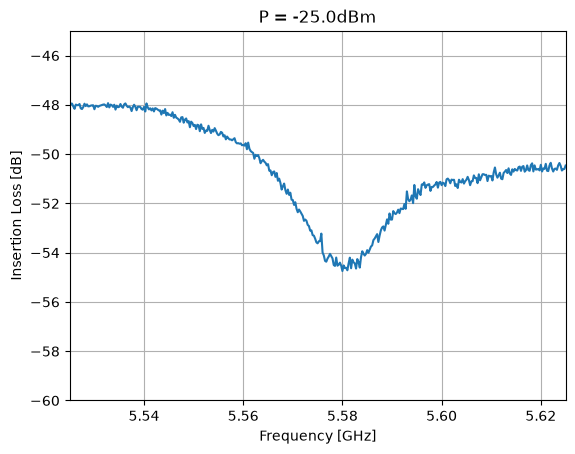

In [37]:
linear_traces = 10 ** (np.array(data_stack[-5]['s_db']) / 10)
linear_average = np.mean(linear_traces, axis=0)
db_average = 10 * np.log10(linear_average)
plt.plot(fghz,db_average)
plt.ylim([-60,-45])
plt.xlim([fghz[0],fghz[-1]])
plt.xlabel('Frequency [GHz]')
plt.ylabel('Insertion Loss [dB]')
plt.grid()
plt.title('P = ' + str(data_stack[-5]['vna']['power']) + 'dBm')

-12.0
-14.0
-16.0
-18.0
-20.0
-22.0
-23.0
-24.0
-25.0
-26.0
-27.0
-30.0


Text(0.5, 1.0, 'Power Sweep on Qubit')

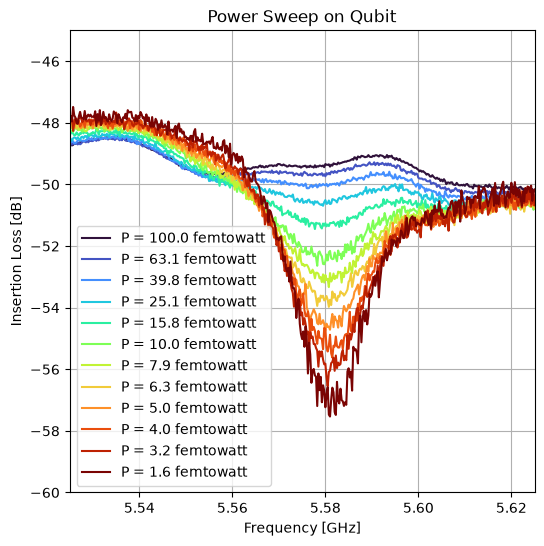

In [63]:
power_scan = {}
power_scan['traces'] = []
power_scan['fghz'] = fghz.tolist()
power_scan['power'] = []
power_scan['legend'] = [] 
power_scan['programmable_attenuator'] = data_stack[-5]['programmable_attenuator']


fig, ax = plt.subplots(figsize=(6, 6))
#plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, len(data_stack[3:-1]))))
#plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.gray(np.linspace(0.1, 0.8, len(data_stack[3:-1]))))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.turbo(np.linspace(0, 1, len(data_stack[3:-1]))))

for data_set in data_stack[3:-1]:
    print(data_set['vna']['power'])
    linear_traces = 10 ** (np.array(data_set['s_db']) / 10)
    linear_average = np.mean(linear_traces, axis=0)
    db_average = 10 * np.log10(linear_average)
    plt.plot(fghz,db_average)
    power_scan['traces'].append(db_average.tolist())
    power_scan['power'].append(data_set['vna']['power'])
    power_watts = 1e-3*10**((data_set['vna']['power'] - 63 - 25)/10)
    power_fw = 1e15*power_watts
    #power_scan['legend'].append("P = " + str(data_set['vna']['power'] - 63 - 25) + " dBm")
    power_scan['legend'].append(f"P = {power_fw:.1f} femtowatt")
plt.ylim([-60,-45])
plt.xlim([fghz[0],fghz[-1]])
plt.xlabel('Frequency [GHz]')
plt.ylabel('Insertion Loss [dB]')
plt.grid()
plt.legend(power_scan['legend'])
plt.title('Power Sweep on Qubit')

In [64]:
power_scan.keys()

dict_keys(['traces', 'fghz', 'power', 'legend', 'programmable_attenuator'])

In [65]:
with open("power_scan", "w", encoding="utf-8") as f:
    json.dump(power_scan, f, indent=4)